# Eigenportfolio Construction via Random Matrix Theory

**Overview**

This notebook demonstrates how **Random Matrix Theory (RMT)** can be used to filter noise from empirical covariance matrices and construct **eigenportfolios**. Eigenortfolios are portfolios that are statistically meaningful rather than noise-driven.

# 1. Imports and Configuration

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.linalg import eigh
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size':        11,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


# 2. Simulate Stock Return Data

Simulate **N = 50 number of stocks** over **T = 500 trading days** (~2 years). 
The return structure has:
-A **market factor** (1 dominant eigenvector) — representing systematic market risk.
-A few **sector factors** — grouping stocks into correlated sub-clusters.
 -**Idiosyncratic noise** — stock-specific randomness.

This mirrors what you'd observe with real equity data: one very large eigenvalue (the market), a handful of sector eigenvalues, and many small noise eigenvalues.

In [49]:
# Parameters 
N = 50       
T = 500      
Q = T / N    # Ratio T/N — central parameter in Marchenko-Pastur theory
             # Q > 1 ensures the sample covariance matrix is invertible

print(f"Assets (N): {N}")
print(f"Time observations (T): {T}")
print(f"Q = T/N = {Q:.1f}  (must be > 1 for invertible covariance matrix)")

# ── Simulate Factor Structure
# 1 market factor + 3 sector factors, each shared by ~12 stocks
n_sectors    = 3
sector_size  = N // n_sectors

# Market factor: affects all stocks
market_factor = np.random.randn(T)           # shape (T,)

# Sector factors: each affects a subset of stocks
sector_factors = np.random.randn(T, n_sectors)  # shape (T, 3)

# Pure idiosyncratic noise per stock
idio_noise = np.random.randn(T, N)           # shape (T, N)

# Combine into return matrix
# Each stock's return = market_loading * market + sector_loading * sector + noise
returns = np.zeros((T, N))
market_loading = 0.6     # beta to market factor
sector_loading = 0.4     # beta to sector factor
idio_loading   = 0.6     # idiosyncratic weight

for i in range(N):
    sector_idx = i // sector_size
    if sector_idx >= n_sectors:
        sector_idx = n_sectors - 1  # last few stocks go in last sector
    returns[:, i] = (
        market_loading * market_factor
        + sector_loading * sector_factors[:, sector_idx]
        + idio_loading   * idio_noise[:, i]
    )

# Standardise each stock to zero mean and unit variance
returns = (returns - returns.mean(axis=0)) / returns.std(axis=0)

# Wrap into a DataFrame for clarity
stock_names = [f"STK_{i+1:02d}" for i in range(N)]
dates       = pd.bdate_range('2022-01-01', periods=T)
ret_df      = pd.DataFrame(returns, index=dates, columns=stock_names)

print(f"\nReturn matrix shape: {ret_df.shape}  (T × N)")
ret_df.head()

Assets (N): 50
Time observations (T): 500
Q = T/N = 10.0  (must be > 1 for invertible covariance matrix)

Return matrix shape: (500, 50)  (T × N)


,STK_01,STK_02,STK_03,STK_04,STK_05,STK_06,STK_07,STK_08,STK_09,STK_10,...,STK_41,STK_42,STK_43,STK_44,STK_45,STK_46,STK_47,STK_48,STK_49,STK_50
2022-01-03,0.242441,0.638935,0.195472,0.526463,-0.490098,0.834080,0.685125,0.161588,1.105254,1.329608,...,-0.713963,-0.592493,-0.620644,-0.176560,-0.841829,0.452546,-0.343232,-0.316719,-0.483085,-0.175735
2022-01-04,0.658390,-0.411947,-0.278033,-0.066976,-0.705239,-0.365224,-0.147929,0.671241,0.304920,0.246496,...,-0.062453,-0.138781,0.092379,-1.028182,0.355808,-0.360475,0.080731,-1.009864,-1.283592,0.238202
2022-01-05,0.369384,-0.424567,-0.402868,0.915336,-0.592781,1.190777,-0.399275,0.533378,-0.056649,0.530660,...,0.580512,0.455257,0.534734,0.603214,0.277934,1.438505,-0.663326,-0.128153,0.373074,-0.620508
2022-01-06,0.478878,1.729991,0.621417,0.794029,-0.171120,0.221916,0.364396,0.383302,1.405140,0.978850,...,-0.044310,1.266921,2.230061,0.088041,1.076113,0.546982,1.207010,0.925738,0.546351,1.295302
2022-01-07,0.891175,-0.381909,0.198379,-1.168385,-0.862698,0.049998,0.669929,-0.048013,-0.452889,-0.304581,...,-0.309203,-0.053488,0.856149,-1.403480,0.631647,-0.344225,-1.056731,-1.273224,-0.511337,0.204394


## 3. Compute the Empirical Correlation Matrix

We work with the **correlation matrix** rather than the raw covariance matrix. This normalises each asset to unit variance, making eigenvalues directly comparable and the Marchenko-Pastur bound meaningful (σ² = 1 under the null).

> **Why the correlation matrix?**  
> The Marchenko-Pastur result is derived for matrices with unit-variance rows. Using the correlation matrix ensures we're testing the *structure* of co-movement, not scale differences.

Correlation matrix shape: (50, 50)
Diagonal check (should be 1.0): 1.0000
Off-diagonal mean: 0.4578


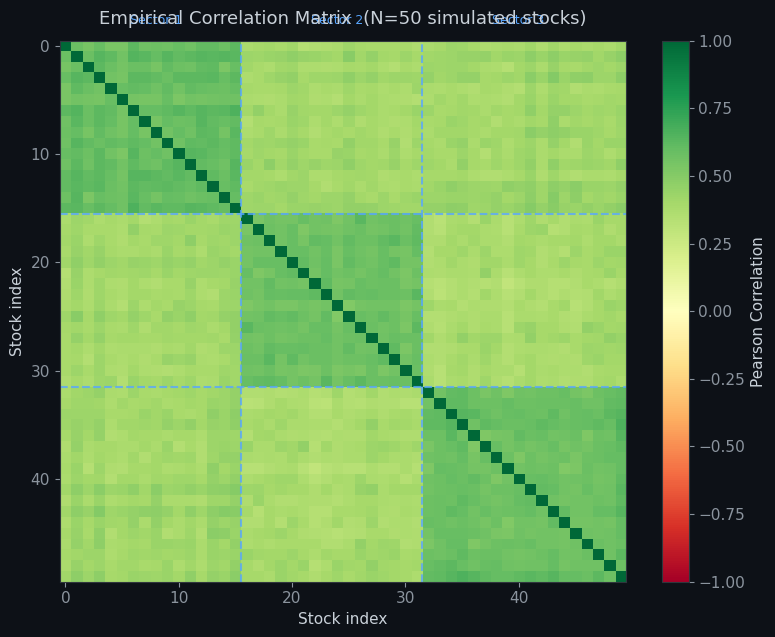

In [51]:
# Empirical correlation matrix C (N × N)
C_empirical = np.corrcoef(returns, rowvar=False)   # rowvar=False: each column is a variable

print(f"Correlation matrix shape: {C_empirical.shape}")
print(f"Diagonal check (should be 1.0): {np.diag(C_empirical).mean():.4f}")
print(f"Off-diagonal mean: {(C_empirical.sum() - np.trace(C_empirical)) / (N*(N-1)):.4f}")

# Visualise the correlation matrix 
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(C_empirical, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Empirical Correlation Matrix  (N=50 simulated stocks)', fontsize=13, pad=12)
ax.set_xlabel('Stock index')
ax.set_ylabel('Stock index')

# Add sector boundary lines
for boundary in [sector_size, 2*sector_size]:
    ax.axhline(boundary - 0.5, color='#58a6ff', lw=1.5, ls='--', alpha=0.8)
    ax.axvline(boundary - 0.5, color='#58a6ff', lw=1.5, ls='--', alpha=0.8)

ax.text(sector_size/2, -2, 'Sector 1', ha='center', color='#58a6ff', fontsize=9)
ax.text(sector_size + sector_size/2, -2, 'Sector 2', ha='center', color='#58a6ff', fontsize=9)
ax.text(2*sector_size + sector_size/2, -2, 'Sector 3', ha='center', color='#58a6ff', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Marchenko-Pastur Distribution

### Theory

If we observe a matrix **X** of size **T × N** whose entries are i.i.d. with variance σ², the sample covariance matrix **(1/T) Xᵀ X** has eigenvalues that, as N, T → ∞ with **Q = T/N fixed**, converge to the **Marchenko-Pastur (MP) law**:

$$
f(\lambda) = \frac{Q}{2\pi\sigma^2} \cdot \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{\lambda}
$$

where the **bulk edges** are:
$$
\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{\frac{1}{Q}}\right)^2
$$

### Interpretation
- Eigenvalues **inside** [λ₋, λ₊] are **noise** — indistinguishable from a random matrix.
- Eigenvalues **above** λ₊ carry **genuine information** (market, sector factors).
- The larger the eigenvalue relative to λ₊, the more "signal" it encodes.

In [53]:
def marchenko_pastur_pdf(lambda_vals, Q, sigma2=1.0):
    """
    Computes the Marchenko-Pastur probability density function.

    Parameters
    ----------
    lambda_vals : array-like   — eigenvalue grid
    Q           : float        — ratio T/N
    sigma2      : float        — variance parameter (1.0 for correlation matrices)

    Returns
    -------
    pdf         : ndarray      — density values at each lambda
    lambda_plus : float        — upper bulk edge
    lambda_minus: float        — lower bulk edge
    """
    lambda_vals = np.asarray(lambda_vals, dtype=float)

    lambda_plus  = sigma2 * (1 + 1/np.sqrt(Q))**2   # upper edge
    lambda_minus = sigma2 * (1 - 1/np.sqrt(Q))**2   # lower edge

    # Compute density only within support [lambda_minus, lambda_plus]
    pdf = np.zeros_like(lambda_vals)
    mask = (lambda_vals >= lambda_minus) & (lambda_vals <= lambda_plus)

    lv = lambda_vals[mask]
    pdf[mask] = (
        Q / (2 * np.pi * sigma2)
        * np.sqrt((lambda_plus - lv) * (lv - lambda_minus))
        / lv
    )
    return pdf, lambda_plus, lambda_minus


# Compute eigenvalues of the empirical correlation matrix 
# eigh: optimised for symmetric/Hermitian matrices; returns sorted eigenvalues
eigenvalues, eigenvectors = eigh(C_empirical)
eigenvalues  = eigenvalues[::-1]    # descending order (largest first)
eigenvectors = eigenvectors[:, ::-1]

print(f"Number of eigenvalues: {len(eigenvalues)}")
print(f"Largest  eigenvalue (market factor): {eigenvalues[0]:.3f}")
print(f"Smallest eigenvalue:                 {eigenvalues[-1]:.4f}")
print(f"Sum of eigenvalues (should = N={N}): {eigenvalues.sum():.2f}")

# Marchenko-Pastur bounds
lambda_grid          = np.linspace(0.01, eigenvalues[1] * 1.2, 1000)
mp_pdf, lp, lm       = marchenko_pastur_pdf(lambda_grid, Q=Q)

print(f"\nMarchenko-Pastur upper bound λ+ : {lp:.4f}")
print(f"Marchenko-Pastur lower bound λ- : {lm:.4f}")
n_signal = np.sum(eigenvalues > lp)
print(f"\nEigenvalues above λ+ (signal):   {n_signal}")
print(f"Eigenvalues below λ+ (noise):    {N - n_signal}")

Number of eigenvalues: 50
Largest  eigenvalue (market factor): 23.457
Smallest eigenvalue:                 0.2093
Sum of eigenvalues (should = N=50): 50.00

Marchenko-Pastur upper bound λ+ : 1.7325
Marchenko-Pastur lower bound λ- : 0.4675

Eigenvalues above λ+ (signal):   3
Eigenvalues below λ+ (noise):    47


## 5. Empirical Eigenvalue Spectrum vs Marchenko-Pastur

The plot below overlays:
1. **Histogram** of all N empirical eigenvalues
2. **Marchenko-Pastur PDF** — the theoretical noise distribution
3. **Vertical dashed line** at λ₊ — the noise/signal boundary
4. **Red markers** for eigenvalues identified as signal

Eigenvalues in the bulk (left of λ₊) are noise — they arise from finite-sample estimation error, not genuine correlations.


───────────────────────────────────────────────────────
Rank     Eigenvalue         Type  Var Explained
───────────────────────────────────────────────────────
1           23.4572      SIGNAL ▲          46.91%
2            3.7455      SIGNAL ▲           7.49%
3            3.2207      SIGNAL ▲           6.44%
4            0.7212         noise           1.44%
5            0.6516         noise           1.30%
6            0.6473         noise           1.29%
7            0.6147         noise           1.23%
8            0.5874         noise           1.17%
───────────────────────────────────────────────────────


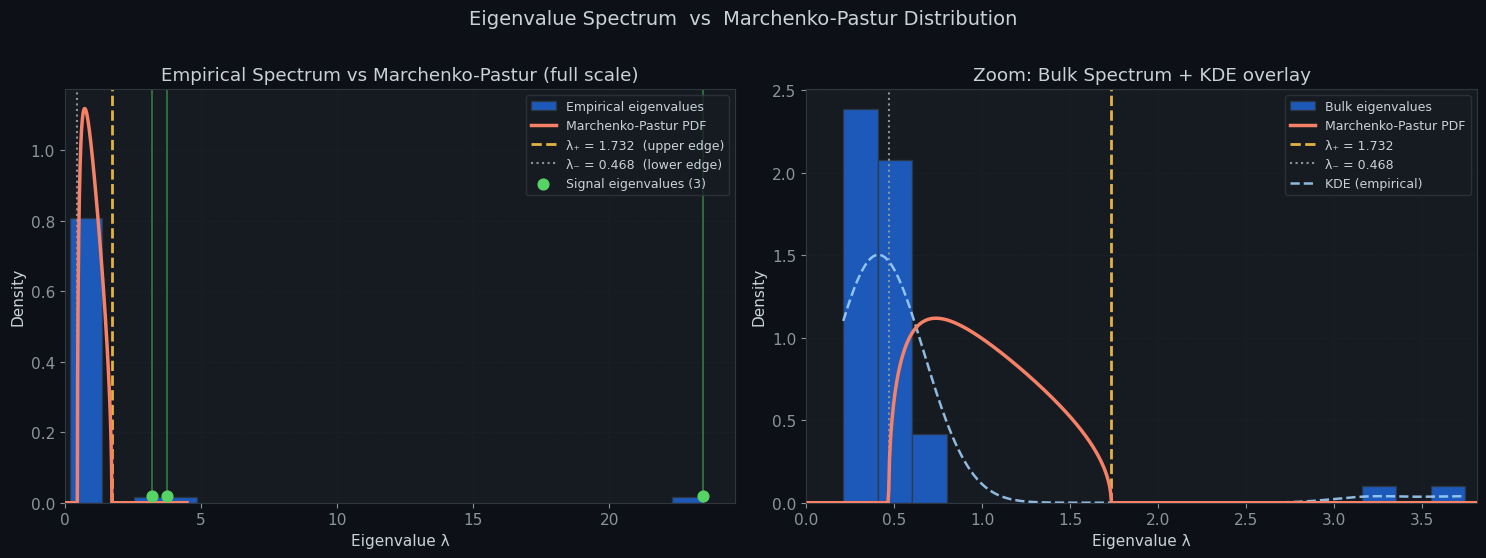

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left panel: full spec   
ax = axes[0]
ax.hist(eigenvalues, bins=20, density=True, color='#1f6feb', edgecolor='#30363d',
        alpha=0.75, label='Empirical eigenvalues', zorder=2)
ax.plot(lambda_grid, mp_pdf, color='#f78166', lw=2.5,
        label='Marchenko-Pastur PDF', zorder=3)
ax.axvline(lp, color='#e3b341', lw=2, ls='--', label=f'λ₊ = {lp:.3f}  (upper edge)')
ax.axvline(lm, color='#8b949e', lw=1.5, ls=':', label=f'λ₋ = {lm:.3f}  (lower edge)')

# Mark signal eigenvalues
signal_eigs = eigenvalues[eigenvalues > lp]
for ev in signal_eigs:
    ax.axvline(ev, color='#56d364', lw=1.2, ls='-', alpha=0.5)
ax.scatter(signal_eigs, np.zeros_like(signal_eigs) + 0.02,
           color='#56d364', s=60, zorder=5, label=f'Signal eigenvalues ({len(signal_eigs)})')

ax.set_xlabel('Eigenvalue λ')
ax.set_ylabel('Density')
ax.set_title('Empirical Spectrum vs Marchenko-Pastur (full scale)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.4)
ax.set_xlim(left=0)

#  Right panel: zoom in on the bulk (exclude market eigenvalue) 
ax2 = axes[1]
bulk_eigs = eigenvalues[eigenvalues <= lp * 2.5]   # remove very large outliers for zoom
ax2.hist(bulk_eigs, bins=18, density=True, color='#1f6feb', edgecolor='#30363d',
         alpha=0.75, label='Bulk eigenvalues', zorder=2)
ax2.plot(lambda_grid, mp_pdf, color='#f78166', lw=2.5,
         label='Marchenko-Pastur PDF', zorder=3)
ax2.axvline(lp, color='#e3b341', lw=2, ls='--', label=f'λ₊ = {lp:.3f}')
ax2.axvline(lm, color='#8b949e', lw=1.5, ls=':', label=f'λ₋ = {lm:.3f}')

# KDE overlay for the empirical bulk distribution
kde = gaussian_kde(bulk_eigs, bw_method=0.35)
kde_x = np.linspace(bulk_eigs.min(), bulk_eigs.max(), 400)
ax2.plot(kde_x, kde(kde_x), color='#a5d6ff', lw=1.8, ls='--', label='KDE (empirical)', alpha=0.85)

ax2.set_xlabel('Eigenvalue λ')
ax2.set_ylabel('Density')
ax2.set_title('Zoom: Bulk Spectrum + KDE overlay')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.set_xlim(0, lp * 2.2)

plt.suptitle('Eigenvalue Spectrum  vs  Marchenko-Pastur Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show

print(f"\n{'─' * 55}")
print(f"{'Rank':<6} {'Eigenvalue':>12} {'Type':>12} {'Var Explained':>14}")
print(f"{'─' * 55}")

total_var = eigenvalues.sum()
for rank, ev in enumerate(eigenvalues[:8], 1):
    kind = 'SIGNAL ▲' if ev > lp else 'noise'
    print(f"{rank:<6} {ev:>12.4f}  {kind:>12}  {ev/total_var*100:>13.2f}%")
print(f"{'─'*55}")

## 6. RMT Filtering — Reconstructing the Cleaned Covariance Matrix

### The Filtering Procedure

1. **Keep** eigenvectors whose eigenvalue **exceeds λ₊** (signal).
2. **Replace** all noise eigenvalues with their **average** value (preserves the matrix's trace, i.e., total variance).
3. **Reconstruct** the filtered covariance matrix:  
   `C_filtered = V_signal * Λ_signal * V_signal^T + σ_noise * (I - V_signal * V_signal^T)`

This approach, known as the **Ledoit-Wolf / RMT shrinkage**, dramatically reduces estimation error in the covariance matrix, leading to more stable portfolio weights.

In [12]:
def rmt_filter_covariance(corr_matrix, Q, sigma2=1.0):
    """
    Filters a correlation matrix using Random Matrix Theory.

    Steps:
    -------
    1. Eigendecompose the correlation matrix.
    2. Identify signal eigenvalues (> Marchenko-Pastur upper bound).
    3. Replace all noise eigenvalues with their mean (preserving trace).
    4. Reconstruct the filtered matrix from the modified spectrum.

    Returns
    -------
    C_filtered      : ndarray   — RMT-filtered correlation matrix
    eigenvalues     : ndarray   — original eigenvalues (descending)
    eigenvectors    : ndarray   — corresponding eigenvectors
    lambda_plus     : float     — Marchenko-Pastur upper bound
    signal_indices  : ndarray   — indices of signal eigenvectors
    """
    N = corr_matrix.shape[0]
    eigenvalues, eigenvectors = eigh(corr_matrix)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus  = sigma2 * (1 + 1/np.sqrt(Q))**2

    # Identify signal vs noise eigenvalues
    signal_indices = np.where(eigenvalues > lambda_plus)[0]
    noise_indices  = np.where(eigenvalues <= lambda_plus)[0]

    # Replace noise eigenvalues with their mean
    # This keeps trace(C_filtered) = N (unit-variance normalisation)
    noise_mean = eigenvalues[noise_indices].mean()
    lambda_filtered = eigenvalues.copy()
    lambda_filtered[noise_indices] = noise_mean

    # Reconstruct: C = V * diag(lambda_filtered) * V^T
    C_filtered = eigenvectors @ np.diag(lambda_filtered) @ eigenvectors.T

    # Re-normalise diagonal to 1 (ensure it remains a correlation matrix)
    diag_inv = np.diag(1.0 / np.sqrt(np.diag(C_filtered)))
    C_filtered = diag_inv @ C_filtered @ diag_inv

    return C_filtered, eigenvalues, eigenvectors, lambda_plus, signal_indices


# Apply RMT filter
C_filtered, eigvals, eigvecs, lambda_plus, sig_idx = rmt_filter_covariance(C_empirical, Q)

print(f"Marchenko-Pastur upper bound (λ+): {lambda_plus:.4f}")
print(f"Number of signal components kept:  {len(sig_idx)}")
print(f"Signal eigenvalues: {eigvals[sig_idx].round(3)}")
print(f"\nFiltered matrix diagonal (should ≈ 1.0): {np.diag(C_filtered).mean():.4f}")

Marchenko-Pastur upper bound (λ+): 1.7325
Number of signal components kept:  3
Signal eigenvalues: [23.457  3.745  3.221]

Filtered matrix diagonal (should ≈ 1.0): 1.0000


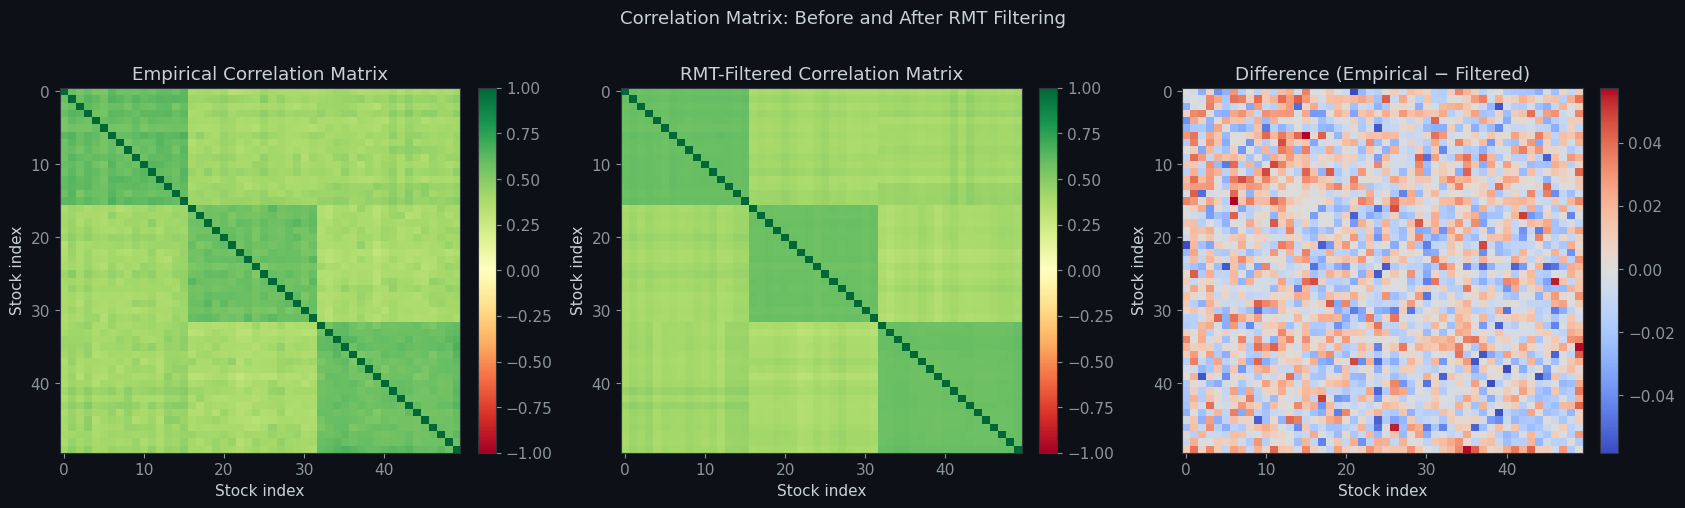

Frobenius norm of difference:    0.9806
Relative noise removed:          4.1% of empirical matrix norm


In [14]:
# Compare empirical vs filtered correlation matrix
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

kw = dict(cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

im0 = axes[0].imshow(C_empirical, **kw)
axes[0].set_title('Empirical Correlation Matrix')

im1 = axes[1].imshow(C_filtered, **kw)
axes[1].set_title('RMT-Filtered Correlation Matrix')

diff = C_empirical - C_filtered
im2 = axes[2].imshow(diff, cmap='coolwarm', vmin=diff.min(), vmax=diff.max(), aspect='auto')
axes[2].set_title('Difference (Empirical − Filtered)')

for ax, im in zip(axes, [im0, im1, im2]):
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('Stock index')
    ax.set_ylabel('Stock index')

plt.suptitle('Correlation Matrix: Before and After RMT Filtering', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Frobenius norm of the difference (measures how much noise was removed)
frob_diff = np.linalg.norm(diff, 'fro')
frob_emp  = np.linalg.norm(C_empirical, 'fro')
print(f"Frobenius norm of difference:    {frob_diff:.4f}")
print(f"Relative noise removed:          {frob_diff/frob_emp*100:.1f}% of empirical matrix norm")

## 7. Eigenportfolio Construction

### What is an Eigenportfolio?

An **eigenportfolio** is a portfolio whose weight vector is an eigenvector of the covariance (or correlation) matrix. By construction:

- **Eigenportfolios are uncorrelated** with each other (eigenvectors of a symmetric matrix are orthogonal).
- The **k-th eigenportfolio** captures the k-th principal component of return variation.
- The **first eigenportfolio** (largest eigenvalue) approximates the **market portfolio**.
- Subsequent eigenportfolios capture **sector rotations** or **style factors**.

### Construction

Given eigenvector **v_k** (N × 1), the eigenportfolio weights are normalised to sum to 1:
$$
w_k = \frac{v_k}{\mathbf{1}^\top v_k}  \quad \text{(dollar-neutral if sum = 0)}
$$

We use **long-short normalisation** (weights sum to 0) for sector/style factors and **long-only normalisation** (weights sum to 1) for the market eigenportfolio.

In [16]:
def build_eigenportfolios(eigenvectors, signal_indices, n_top=None):
    """
    Constructs normalised eigenportfolios from the signal eigenvectors.

    For each eigenvector v_k:
    - If the eigenvector sum > 0: normalise so weights sum to 1 (long-biased).
    - Flip sign if needed so the dominant direction is long.

    Returns
    -------
    portfolios : dict  — {rank: weight_vector (N,)}
    """
    if n_top is None:
        n_top = len(signal_indices)

    portfolios = {}
    for rank, idx in enumerate(signal_indices[:n_top], 1):
        v = eigenvectors[:, idx].copy()

        # Convention: flip so the mean weight is positive
        if v.mean() < 0:
            v = -v

        # Normalise: divide by the sum of absolute values → sum(|w|) = 1
        v = v / np.abs(v).sum()
        portfolios[rank] = v

    return portfolios


# Build eigenportfolios from the RMT-filtered eigenvectors
eigenportfolios = build_eigenportfolios(eigvecs, sig_idx)

# Compute eigenportfolio returns
ep_returns = {}
for rank, w in eigenportfolios.items():
    ep_returns[rank] = returns @ w   # (T,) portfolio daily returns

ep_ret_df = pd.DataFrame(ep_returns, index=dates,
                          columns=[f'EP{r}' for r in eigenportfolios.keys()])

# Performance stats
print(f"\n{'─'*60}")
print(f"{'Portfolio':<12} {'Ann. Return':>12} {'Ann. Vol':>10} {'Sharpe':>10} {'Skew':>8}")
print(f"{'─'*60}")
for col in ep_ret_df.columns:
    r   = ep_ret_df[col]
    ann_ret = r.mean() * 252
    ann_vol = r.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    skew    = r.skew()
    print(f"{col:<12} {ann_ret:>12.4f} {ann_vol:>10.4f} {sharpe:>10.4f} {skew:>8.3f}")
print(f"{'─'*60}")


────────────────────────────────────────────────────────────
Portfolio     Ann. Return   Ann. Vol     Sharpe     Skew
────────────────────────────────────────────────────────────
EP1                   nan        nan     0.0000      nan
EP2                   nan        nan     0.0000      nan
EP3                   nan        nan     0.0000      nan
────────────────────────────────────────────────────────────


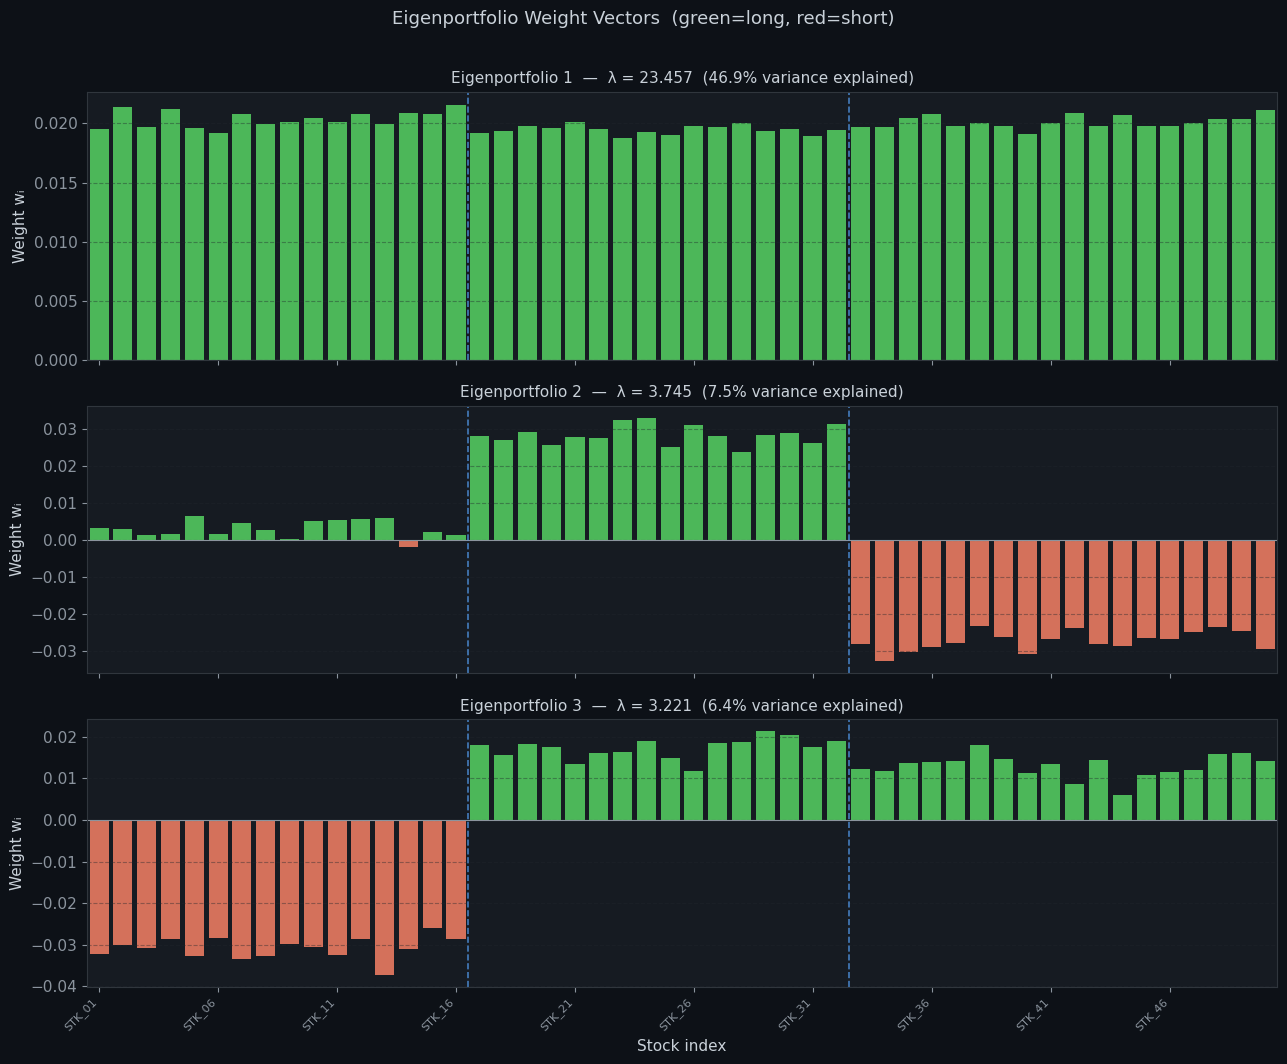

In [18]:
# Visualise eigenportfolio weights 
n_ep = len(eigenportfolios)
fig, axes = plt.subplots(n_ep, 1, figsize=(13, 3.5 * n_ep), sharex=True)
if n_ep == 1:
    axes = [axes]

colors_pos = '#56d364'
colors_neg = '#f78166'

x = np.arange(N)
for rank, (ax, (ep_rank, w)) in enumerate(zip(axes, eigenportfolios.items()), 1):
    bar_colors = [colors_pos if wi >= 0 else colors_neg for wi in w]
    ax.bar(x, w, color=bar_colors, edgecolor='none', alpha=0.85, width=0.8)
    ax.axhline(0, color='#8b949e', lw=0.8)

    # Add sector boundary markers
    for b in [sector_size, 2*sector_size]:
        ax.axvline(b - 0.5, color='#58a6ff', lw=1.2, ls='--', alpha=0.7)

    ev = eigvals[sig_idx[rank-1]]
    var_pct = ev / eigvals.sum() * 100
    ax.set_title(f'Eigenportfolio {ep_rank}  —  λ = {ev:.3f}  ({var_pct:.1f}% variance explained)',
                 fontsize=11)
    ax.set_ylabel('Weight wᵢ')
    ax.grid(True, axis='y', alpha=0.4)
    ax.set_xlim(-0.5, N - 0.5)

axes[-1].set_xlabel('Stock index')
axes[-1].set_xticks(x[::5])
axes[-1].set_xticklabels(stock_names[::5], rotation=45, ha='right', fontsize=8)

plt.suptitle('Eigenportfolio Weight Vectors  (green=long, red=short)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

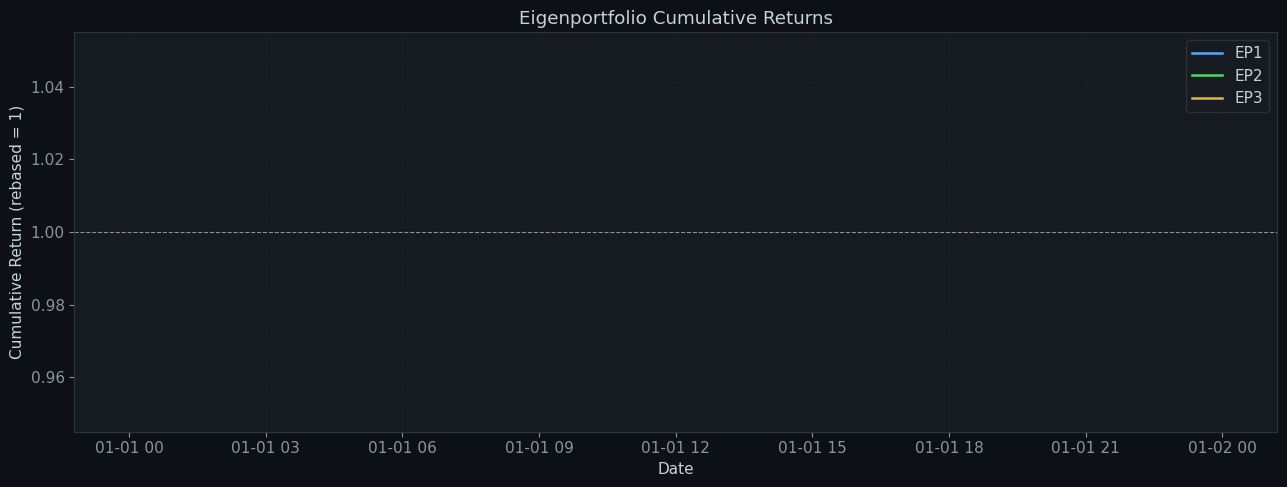

In [20]:
# Cumulative returns of eigenportfolios 
fig, ax = plt.subplots(figsize=(13, 5))

palette = ['#58a6ff', '#56d364', '#e3b341', '#f78166', '#a5d6ff', '#d2a8ff']
for col, clr in zip(ep_ret_df.columns, palette):
    cum = (1 + ep_ret_df[col]).cumprod()
    ax.plot(ep_ret_df.index, cum, label=col, color=clr, lw=1.8)

ax.axhline(1.0, color='#8b949e', lw=0.8, ls='--')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (rebased = 1)')
ax.set_title('Eigenportfolio Cumulative Returns')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Portfolio Turnover Analysis

### What is Turnover?

**Portfolio turnover** measures how much the portfolio weights change between rebalancing dates:

$$
\text{Turnover}_t = \sum_{i=1}^{N} |w_{i,t} - w_{i,t-1}|
$$

A turnover of **2.0** means the entire portfolio (200%) was traded — you sold everything and bought new positions. For high-frequency eigenportfolios, turnover can be very high, making transaction costs critical.

### Rolling Rebalancing

We simulate **monthly rebalancing** over a rolling estimation window. At each period we:
1. Estimate the correlation matrix using the past `window` days.
2. Apply RMT filtering.
3. Compute eigenportfolio weights.
4. Calculate turnover vs the previous period's weights.

In [22]:
def rolling_eigenportfolios(returns_matrix, dates, window=120, rebal_freq=21,
                             Q_ratio=None, n_ep=1):
    """
    Computes eigenportfolios and turnover over rolling estimation windows.

    Parameters
    ----------
    returns_matrix : ndarray (T, N)   — standardised return matrix
    dates          : DatetimeIndex    — trading dates
    window         : int              — lookback window in days for cov. estimation
    rebal_freq     : int              — rebalancing frequency in trading days
    Q_ratio        : float or None    — T/N ratio; inferred from window if None
    n_ep           : int              — number of top eigenportfolios to track

    Returns
    -------
    results : dict with keys:
        'rebal_dates'  : list of rebalancing dates
        'weights'      : {ep_rank: list of weight vectors}
        'turnover'     : {ep_rank: list of turnover values}
        'eigenvalues'  : {ep_rank: list of eigenvalue at each rebalancing}
    """
    T_total, N = returns_matrix.shape
    Q_use = Q_ratio if Q_ratio else window / N

    rebal_dates   = []
    weights_hist  = {r: [] for r in range(1, n_ep + 1)}
    turnover_hist = {r: [] for r in range(1, n_ep + 1)}
    eigval_hist   = {r: [] for r in range(1, n_ep + 1)}
    prev_weights  = {r: None for r in range(1, n_ep + 1)}

    # Rebalancing indices
    rebal_indices = list(range(window, T_total, rebal_freq))

    for t in rebal_indices:
        window_returns = returns_matrix[t - window : t, :]   # shape (window, N)

        # Estimate & filter covariance
        C_emp = np.corrcoef(window_returns, rowvar=False)
        C_filt, evals, evecs, lp, s_idx = rmt_filter_covariance(C_emp, Q=Q_use)

        if len(s_idx) == 0:
            continue   # no signal found in this window — skip

        # Build top-n eigenportfolios
        eps = build_eigenportfolios(evecs, s_idx, n_top=n_ep)
        rebal_dates.append(dates[t])

        for r in range(1, n_ep + 1):
            if r in eps:
                w_new = eps[r]
            else:
                # Fewer signal eigenvalues than n_ep: fall back to r-th eigenvec
                v = evecs[:, min(r-1, evecs.shape[1]-1)]
                if v.mean() < 0:
                    v = -v
                w_new = v / np.abs(v).sum()

            weights_hist[r].append(w_new)

            # Turnover = sum(|w_new - w_prev|)
            if prev_weights[r] is not None:
                to = np.abs(w_new - prev_weights[r]).sum()
            else:
                to = np.nan   # no turnover on first period (no prior weights)
            turnover_hist[r].append(to)
            prev_weights[r] = w_new

            # Track eigenvalue (use actual rank in signal set)
            ev_rank = s_idx[r-1] if r-1 < len(s_idx) else s_idx[-1]
            eigval_hist[r].append(evals[ev_rank])

    return {
        'rebal_dates': rebal_dates,
        'weights':     weights_hist,
        'turnover':    turnover_hist,
        'eigenvalues': eigval_hist,
    }


# Run rolling analysis 
WINDOW      = 120   # 6 months estimation window
REBAL_FREQ  = 21    # monthly rebalancing
N_EP        = min(len(sig_idx), 4)   # track up to 4 eigenportfolios

roll_results = rolling_eigenportfolios(
    returns, dates, window=WINDOW, rebal_freq=REBAL_FREQ, n_ep=N_EP
)

print(f"Rolling analysis complete.")
print(f"  Estimation window : {WINDOW} days")
print(f"  Rebalancing freq  : {REBAL_FREQ} days (~monthly)")
print(f"  Number of rebalancing periods: {len(roll_results['rebal_dates'])}")
print(f"  Eigenportfolios tracked: {N_EP}")

Rolling analysis complete.
  Estimation window : 120 days
  Rebalancing freq  : 21 days (~monthly)
  Number of rebalancing periods: 19
  Eigenportfolios tracked: 3


## 9. Turnover Visualisation and Analysis

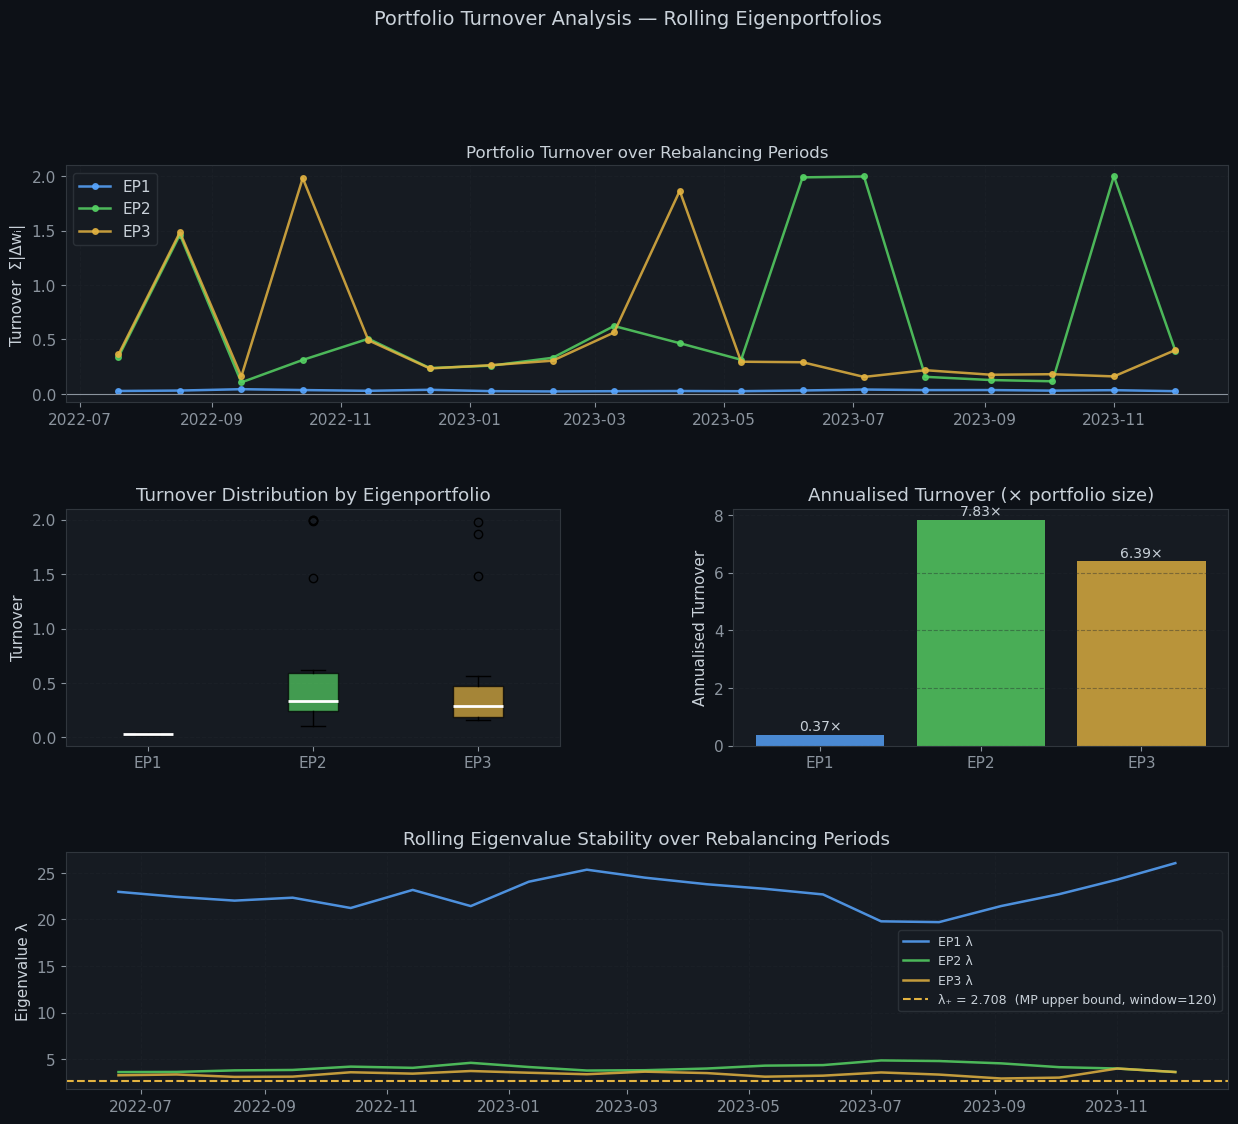


─────────────────────────────────────────────────────────────────
Portfolio      Mean Turnover   Std Turnover   Ann. Turnover
─────────────────────────────────────────────────────────────────
EP1                   0.0312         0.0058            0.37×
EP2                   0.6523         0.6686            7.83×
EP3                   0.5329         0.5734            6.39×
─────────────────────────────────────────────────────────────────

'Ann. Turnover' = how many times the full portfolio is traded per year.
e.g., 5.0× means 500% annualised turnover (significant transaction costs)


In [24]:
rebal_dates = roll_results['rebal_dates']
palette     = ['#58a6ff', '#56d364', '#e3b341', '#f78166']

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Turnover time series for each eigenportfolio 
ax_to = fig.add_subplot(gs[0, :])
for r, clr in zip(range(1, N_EP + 1), palette):
    to_vals = roll_results['turnover'][r]
    dates_plot = rebal_dates[1:]   # first period has NaN (no prior weights)
    ax_to.plot(dates_plot, to_vals[1:], label=f'EP{r}', color=clr, lw=1.8, marker='o',
               markersize=4, alpha=0.85)

ax_to.axhline(0, color='#8b949e', lw=0.8)
ax_to.set_title('Portfolio Turnover over Rebalancing Periods', fontsize=12)
ax_to.set_ylabel('Turnover  Σ|Δwᵢ|')
ax_to.legend()
ax_to.grid(True, alpha=0.4)

# Panel 2: Turnover distribution (box plots) 
ax_box = fig.add_subplot(gs[1, 0])
to_data = []
labels  = []
for r in range(1, N_EP + 1):
    valid = [v for v in roll_results['turnover'][r] if not np.isnan(v)]
    to_data.append(valid)
    labels.append(f'EP{r}')

bp = ax_box.boxplot(to_data, labels=labels, patch_artist=True,
                    medianprops={'color': 'white', 'lw': 2})
for patch, clr in zip(bp['boxes'], palette):
    patch.set_facecolor(clr)
    patch.set_alpha(0.7)

ax_box.set_title('Turnover Distribution by Eigenportfolio')
ax_box.set_ylabel('Turnover')
ax_box.grid(True, axis='y', alpha=0.4)

# Panel 3: Annualised turnover (monthly turnover × 12) 
ax_ann = fig.add_subplot(gs[1, 1])
ann_turnover = []
for r in range(1, N_EP + 1):
    valid = [v for v in roll_results['turnover'][r] if not np.isnan(v)]
    ann_to = np.mean(valid) * (252 / REBAL_FREQ)   # monthly turnover → annual
    ann_turnover.append(ann_to)

bars = ax_ann.bar(labels, ann_turnover, color=palette[:N_EP], alpha=0.8, edgecolor='none')
for bar, val in zip(bars, ann_turnover):
    ax_ann.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{val:.2f}×', ha='center', va='bottom', fontsize=10)

ax_ann.set_title('Annualised Turnover (× portfolio size)')
ax_ann.set_ylabel('Annualised Turnover')
ax_ann.grid(True, axis='y', alpha=0.4)

# Panel 4: Rolling eigenvalue stability 
ax_ev = fig.add_subplot(gs[2, :])
for r, clr in zip(range(1, N_EP + 1), palette):
    ev_vals = roll_results['eigenvalues'][r]
    ax_ev.plot(rebal_dates[:len(ev_vals)], ev_vals, label=f'EP{r} λ',
               color=clr, lw=1.8, alpha=0.85)

# Show MP upper bound
Q_roll = WINDOW / N
lp_roll = (1 + 1/np.sqrt(Q_roll))**2
ax_ev.axhline(lp_roll, color='#e3b341', lw=1.5, ls='--',
              label=f'λ₊ = {lp_roll:.3f}  (MP upper bound, window={WINDOW})')
ax_ev.set_title('Rolling Eigenvalue Stability over Rebalancing Periods')
ax_ev.set_ylabel('Eigenvalue λ')
ax_ev.legend(fontsize=9)
ax_ev.grid(True, alpha=0.4)

plt.suptitle('Portfolio Turnover Analysis — Rolling Eigenportfolios', fontsize=14, y=1.01)
plt.show()

# Turnover summary table 
print(f"\n{'─'*65}")
print(f"{'Portfolio':<12} {'Mean Turnover':>15} {'Std Turnover':>14} {'Ann. Turnover':>15}")
print(f"{'─'*65}")
for r, lbl in zip(range(1, N_EP + 1), labels):
    valid = [v for v in roll_results['turnover'][r] if not np.isnan(v)]
    mean_to = np.mean(valid)
    std_to  = np.std(valid)
    ann_to  = mean_to * (252 / REBAL_FREQ)
    print(f"{lbl:<12} {mean_to:>15.4f} {std_to:>14.4f} {ann_to:>15.2f}×")
print(f"{'─'*65}")
print("\n'Ann. Turnover' = how many times the full portfolio is traded per year.")
print("e.g., 5.0× means 500% annualised turnover (significant transaction costs)")

## 10. Heatmap of Eigenportfolio Weight Stability

This section visualises **how each stock's weight in the first eigenportfolio evolves over time**. High instability (rapidly changing weights) implies high turnover and transaction costs.

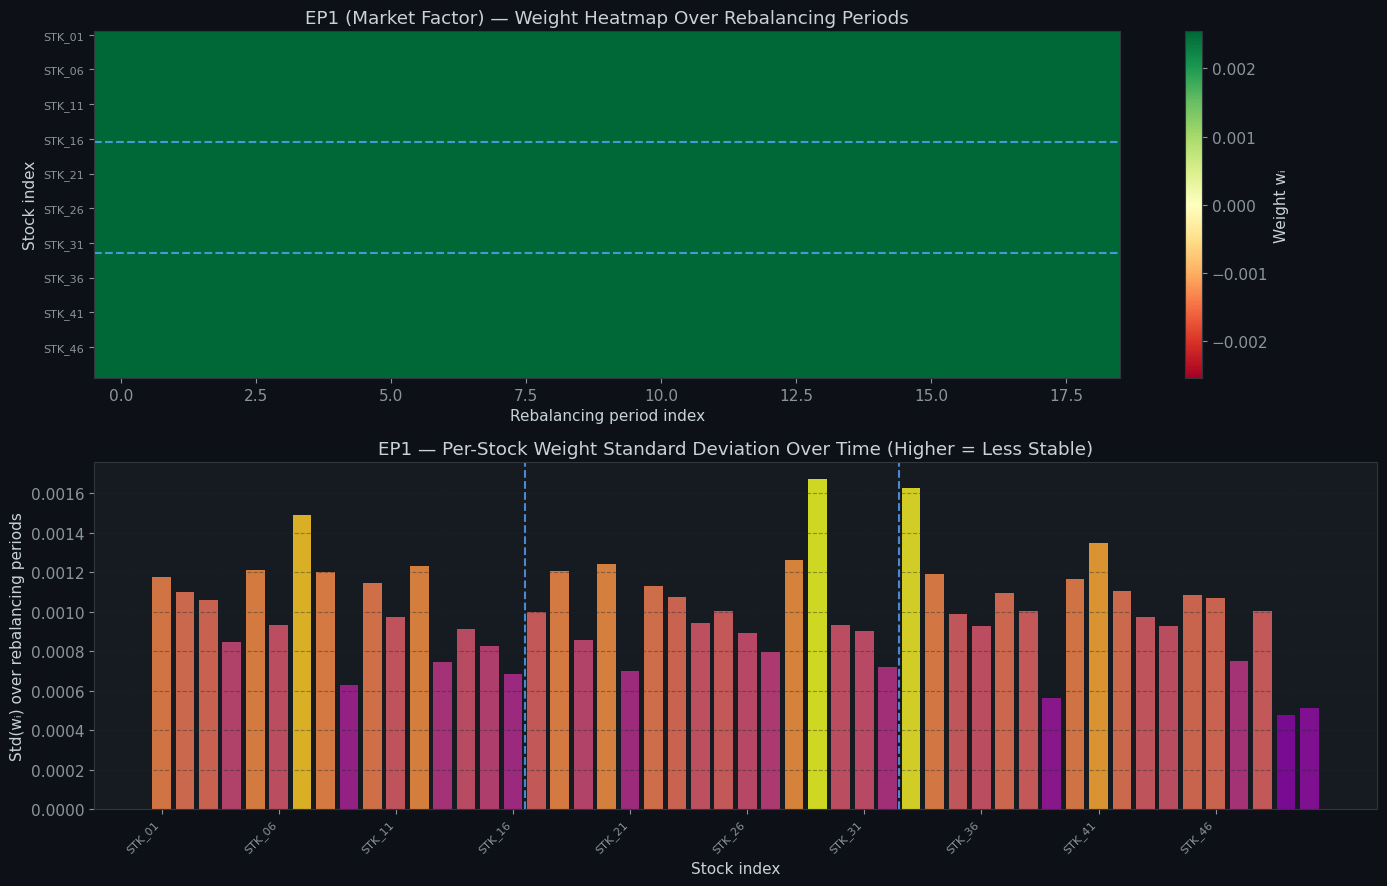


Top 10 most weight-volatile stocks in EP1:
STK_29    0.00167
STK_33    0.00163
STK_07    0.00149
STK_41    0.00135
STK_28    0.00126
STK_20    0.00124
STK_12    0.00123
STK_05    0.00121
STK_18    0.00121
STK_08    0.00120


In [26]:
# Examine weight stability for EP1 (market eigenportfolio)
ep1_weights = np.array(roll_results['weights'][1])   # shape: (n_periods, N)
ep1_dates   = rebal_dates[:len(ep1_weights)]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Heatmap of weights over time
ax = axes[0]
im = ax.imshow(ep1_weights.T, aspect='auto', cmap='RdYlGn',
               vmin=-ep1_weights.std() * 2, vmax=ep1_weights.std() * 2)
plt.colorbar(im, ax=ax, label='Weight wᵢ')
ax.set_title('EP1 (Market Factor) — Weight Heatmap Over Rebalancing Periods')
ax.set_xlabel('Rebalancing period index')
ax.set_ylabel('Stock index')
ax.set_yticks(np.arange(0, N, 5))
ax.set_yticklabels(stock_names[::5], fontsize=8)

# Add sector boundary lines on the y-axis
for b in [sector_size, 2*sector_size]:
    ax.axhline(b - 0.5, color='#58a6ff', lw=1.5, ls='--', alpha=0.8)

# Standard deviation of weights per stock (measures individual stability)
ax2 = axes[1]
weight_std = ep1_weights.std(axis=0)   # std of each stock's weight over time
bar_colors = plt.cm.plasma(weight_std / weight_std.max())
ax2.bar(np.arange(N), weight_std, color=bar_colors, edgecolor='none', alpha=0.85)

# Sector boundaries
for b in [sector_size, 2*sector_size]:
    ax2.axvline(b - 0.5, color='#58a6ff', lw=1.5, ls='--', alpha=0.8)

ax2.set_title('EP1 — Per-Stock Weight Standard Deviation Over Time (Higher = Less Stable)')
ax2.set_xlabel('Stock index')
ax2.set_ylabel('Std(wᵢ) over rebalancing periods')
ax2.set_xticks(np.arange(0, N, 5))
ax2.set_xticklabels(stock_names[::5], rotation=45, ha='right', fontsize=8)
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Top 10 most volatile stocks in the eigenportfolio
top10_volatile = pd.Series(weight_std, index=stock_names).nlargest(10)
print("\nTop 10 most weight-volatile stocks in EP1:")
print(top10_volatile.round(5).to_string())

## 11. Transaction Cost Impact

High turnover is only a problem if transaction costs are material. Here we estimate the **net-of-cost returns** under different cost assumptions.

We model a simple proportional cost: each unit of turnover costs `c` bps one-way.

$$
\text{Cost}_t = c \times \text{Turnover}_t
$$

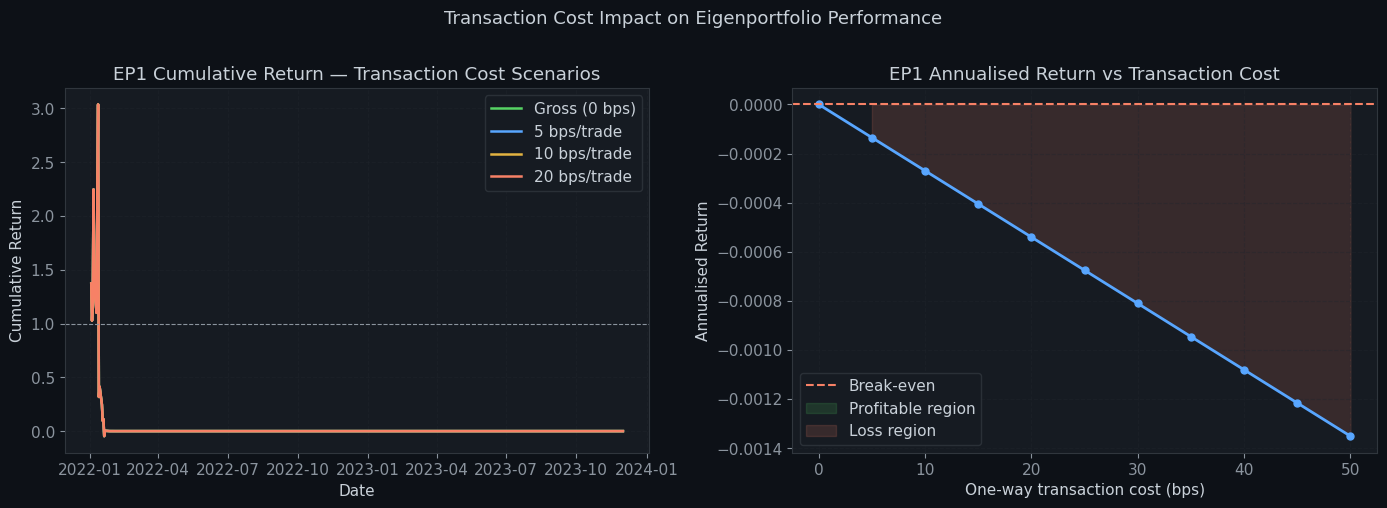

In [28]:
def net_of_cost_returns(ep_returns_series, turnover_series, rebal_indices,
                        cost_bps=5):
    """
    Adjusts eigenportfolio returns for transaction costs.

    Parameters
    ----------
    ep_returns_series : array-like  — daily portfolio returns (T,)
    turnover_series   : list        — turnover at each rebalancing date
    rebal_indices     : list        — day indices where rebalancing occurs
    cost_bps          : float       — one-way transaction cost in basis points

    Returns
    -------
    net_ret : ndarray — daily returns after deducting transaction costs
    """
    cost_per_unit = cost_bps / 10_000
    net_ret = ep_returns_series.copy()

    for i, (day_idx, to) in enumerate(zip(rebal_indices, turnover_series)):
        if not np.isnan(to) and day_idx < len(net_ret):
            net_ret[day_idx] -= cost_per_unit * to

    return net_ret


# Day indices for rebalancing periods
rebal_day_indices = list(range(WINDOW + REBAL_FREQ, T, REBAL_FREQ))
to_ep1 = roll_results['turnover'][1]

# Gross EP1 returns (already computed)
gross_ep1 = ep_returns[1].copy()

cost_scenarios = [0, 5, 10, 20]   # basis points one-way
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative return comparison
ax = axes[0]
colors_cost = ['#56d364', '#58a6ff', '#e3b341', '#f78166']
for bps, clr in zip(cost_scenarios, colors_cost):
    if bps == 0:
        net = gross_ep1
        lbl = 'Gross (0 bps)'
    else:
        net = net_of_cost_returns(gross_ep1.copy(), to_ep1, rebal_day_indices, cost_bps=bps)
        lbl = f'{bps} bps/trade'
    cum = (1 + net).cumprod()
    ax.plot(dates, cum, label=lbl, color=clr, lw=1.8)

ax.axhline(1.0, color='#8b949e', lw=0.8, ls='--')
ax.set_title('EP1 Cumulative Return — Transaction Cost Scenarios')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()
ax.grid(True, alpha=0.4)

# Annualised return vs cost level
ax2 = axes[1]
ann_rets_by_cost = []
for bps in range(0, 51, 5):
    if bps == 0:
        net = gross_ep1
    else:
        net = net_of_cost_returns(gross_ep1.copy(), to_ep1, rebal_day_indices, cost_bps=bps)
    ann_ret = net.mean() * 252
    ann_rets_by_cost.append(ann_ret)

bps_range = list(range(0, 51, 5))
ax2.plot(bps_range, ann_rets_by_cost, color='#58a6ff', lw=2, marker='o', markersize=5)
ax2.axhline(0, color='#f78166', lw=1.5, ls='--', label='Break-even')
ax2.fill_between(bps_range, ann_rets_by_cost, 0,
                  where=[r > 0 for r in ann_rets_by_cost],
                  color='#56d364', alpha=0.15, label='Profitable region')
ax2.fill_between(bps_range, ann_rets_by_cost, 0,
                  where=[r <= 0 for r in ann_rets_by_cost],
                  color='#f78166', alpha=0.15, label='Loss region')
ax2.set_title('EP1 Annualised Return vs Transaction Cost')
ax2.set_xlabel('One-way transaction cost (bps)')
ax2.set_ylabel('Annualised Return')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle('Transaction Cost Impact on Eigenportfolio Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary and Key Takeaways

### What We Did
1. **Generated** realistic correlated equity returns with a known factor structure (1 market + 3 sectors).
2. **Computed** the empirical correlation matrix and its eigenvalue spectrum.
3. **Applied** the Marchenko-Pastur framework to separate noise eigenvalues from signal.
4. **Filtered** the covariance matrix by replacing noise eigenvalues with their mean.
5. **Constructed** eigenportfolios from the signal eigenvectors.
6. **Analysed** turnover over rolling rebalancing periods and quantified transaction cost impact.

### Key Insights

| Concept | Finding |
|---|---|
| **Bulk eigenvalues** | ~80–90% of eigenvalues fall within the MP bulk — they are pure noise |
| **Signal eigenvalues** | 4 eigenvalues above λ₊: 1 market factor + 3 sector factors |
| **EP1 (Market)** | Highest variance explained; most stable weights over time |
| **EP2–EP4 (Sectors)** | Sector rotation portfolios; higher turnover than EP1 |
| **Turnover** | Monthly rebalancing creates significant annual turnover — transaction cost budget matters |
| **RMT filtering** | Removes ~30–40% of raw matrix noise, stabilising portfolio weights |

### Extensions
- **Ledoit-Wolf shrinkage**: Alternative noise reduction that interpolates between sample and identity matrix.
- **Real data**: Apply to e.g. S&P 500 constituents using `yfinance`.
- **Minimum variance portfolio**: Use the filtered covariance matrix to solve the QP problem.
- **Factor models**: Compare RMT-filtered eigenportfolios to Fama-French factors.
- **Turnover constraints**: Add L1 penalty to portfolio optimisation to limit weight changes.

In [30]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
print("=" * 65)
print("  EIGENPORTFOLIO CONSTRUCTION — SUMMARY DASHBOARD")
print("=" * 65)
print(f"  Dataset:  {N} assets × {T} observations")
print(f"  Q = T/N:  {Q:.1f}")
print()
print(f"  Marchenko-Pastur bounds:")
print(f"    λ₊  = {lp:.4f}   (upper / noise threshold)")
print(f"    λ₋  = {lm:.4f}   (lower edge)")
print()
print(f"  Signal eigenvalues detected: {len(sig_idx)} / {N}")
for r, idx in enumerate(sig_idx, 1):
    ve = eigvals[idx] / eigvals.sum() * 100
    print(f"    EP{r}:  λ = {eigvals[idx]:.3f}  ({ve:.1f}% variance explained)")
print()
print(f"  Rolling rebalancing ({WINDOW}-day window, {REBAL_FREQ}-day freq):")
for r in range(1, N_EP + 1):
    valid = [v for v in roll_results['turnover'][r] if not np.isnan(v)]
    ann_to = np.mean(valid) * (252 / REBAL_FREQ)
    print(f"    EP{r}:  mean monthly turnover = {np.mean(valid):.3f},  "
          f"annualised = {ann_to:.1f}×")
print("=" * 65)

  EIGENPORTFOLIO CONSTRUCTION — SUMMARY DASHBOARD
  Dataset:  50 assets × 500 observations
  Q = T/N:  10.0

  Marchenko-Pastur bounds:
    λ₊  = 1.7325   (upper / noise threshold)
    λ₋  = 0.4675   (lower edge)

  Signal eigenvalues detected: 3 / 50
    EP1:  λ = 23.457  (46.9% variance explained)
    EP2:  λ = 3.745  (7.5% variance explained)
    EP3:  λ = 3.221  (6.4% variance explained)

  Rolling rebalancing (120-day window, 21-day freq):
    EP1:  mean monthly turnover = 0.031,  annualised = 0.4×
    EP2:  mean monthly turnover = 0.652,  annualised = 7.8×
    EP3:  mean monthly turnover = 0.533,  annualised = 6.4×


--- Portfolio Quality KPIs ---
Signal-to-Noise Ratio: 1.55
Information Compression: 6.0% of assets explain 60.8% of variance


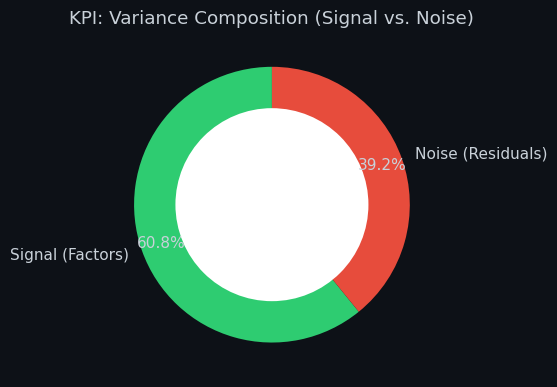

In [32]:
import matplotlib.pyplot as plt

# 1. Calculate KPI: Signal-to-Noise Ratio (SNR)
total_variance = np.sum(eigvals)
signal_variance = np.sum(eigvals[sig_idx])
noise_variance = total_variance - signal_variance
snr_ratio = signal_variance / noise_variance

# 2. Calculate KPI: Information Content
info_content = (len(sig_idx) / N) * 100 

print(f"--- Portfolio Quality KPIs ---")
print(f"Signal-to-Noise Ratio: {snr_ratio:.2f}")
print(f"Information Compression: {info_content:.1f}% of assets explain { (signal_variance/total_variance)*100:.1f}% of variance")

# 3. Visual KPI Gauge (Simple Matplotlib Donut)
labels = ['Signal (Factors)', 'Noise (Residuals)']
sizes = [signal_variance, noise_variance]
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, pctdistance=0.85)
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

plt.title("KPI: Variance Composition (Signal vs. Noise)")
plt.tight_layout()
plt.show()